# WSEI Deep Learning - Lab 08

## Bug domain classification (2x CNN + 1x Spiking Neural Network)

Dataset: [50k bug dataset](https://www.kaggle.com/datasets/mirzayasirabdullah07/50k-bug-dataset/code)

Cel: klasyfikacja `bug_domain` na podstawie kodu/tekstu błędu oraz porównanie 3 modeli:
- CNN VGG-like (1D)
- CNN Inception-like (1D)
- Spiking Neural Network (SNN, snnTorch)

Dodatkowo: wizualizacja predykcji z informacją o `error_code`, porównanie metryk i dyskusja.

In [ ]:
# Odkomentuj przy pierwszym uruchomieniu (Colab/local):
# %pip install torch torchvision torchaudio pandas scikit-learn matplotlib seaborn tqdm snntorch kagglehub

In [4]:
import os
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

try:
    import snntorch as snn
    import snntorch.surrogate as surrogate
    SNN_AVAILABLE = True
except Exception:
    SNN_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("snnTorch available:", SNN_AVAILABLE)

Device: cuda
snnTorch available: True


## 1. Wczytanie i przygotowanie danych

1. Notebook najpierw szuka CSV lokalnie (`DATA_ROOT`).
2. Jeśli nie znajdzie danych i `DOWNLOAD_WITH_KAGGLEHUB=True`, pobiera dataset przez `kagglehub`.
3. Następnie wykrywa kolumny: tekst, `bug_domain`, `error_code`.

In [5]:
# Ustaw ścieżkę do rozpakowanego datasetu (folder z CSV)
DATA_ROOT = Path("./data")
DOWNLOAD_WITH_KAGGLEHUB = True
OUTPUT_DIR = Path("./outputs/lab08")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def find_csv_files(root: Path):
    if not root.exists():
        return []
    return list(root.rglob("*.csv"))


def guess_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in lower_map:
            return lower_map[cand]
    return None


def try_download_with_kagglehub() -> Path | None:
    """Pobiera dataset przez kagglehub i zwraca ścieżkę do plików."""
    try:
        import kagglehub
    except Exception:
        print("Brak pakietu kagglehub. Zainstaluj: pip install kagglehub")
        return None

    try:
        # Download latest version
        path = kagglehub.dataset_download("mirzayasirabdullah07/50k-bug-dataset")
        print("Path to dataset files:", path)
        return Path(path)
    except Exception as e:
        print("Nie udało się pobrać przez kagglehub:", e)
        return None


def resolve_data_root(initial_root: Path) -> Path:
    candidates = [
        initial_root,
        initial_root / "50k-bug-dataset",
        initial_root / "50k_bug_dataset",
        Path("./50k-bug-dataset"),
        Path("./50k_bug_dataset"),
        Path("./dataset"),
    ]

    for c in candidates:
        if find_csv_files(c):
            print(f"Używam danych z: {c.resolve()}")
            return c

    if DOWNLOAD_WITH_KAGGLEHUB:
        downloaded = try_download_with_kagglehub()
        if downloaded and find_csv_files(downloaded):
            return downloaded

    raise FileNotFoundError(
        "Nie znaleziono plików CSV. Ustaw poprawnie DATA_ROOT albo włącz DOWNLOAD_WITH_KAGGLEHUB."
    )


def load_bug_dataset(root: Path) -> pd.DataFrame:
    csv_files = find_csv_files(root)
    if not csv_files:
        raise FileNotFoundError(f"Nie znaleziono CSV w {root.resolve()}")

    frames = []
    for p in csv_files:
        try:
            df = pd.read_csv(p)
            if len(df) == 0:
                continue
            df["_source_file"] = str(p)
            frames.append(df)
        except Exception:
            pass

    if not frames:
        raise RuntimeError("CSV znalezione, ale nie udało się ich wczytać.")

    df = pd.concat(frames, ignore_index=True)

    text_col = guess_column(df.columns, [
        "code", "bug_code", "source_code", "snippet", "text", "description", "bug_description"
    ])
    domain_col = guess_column(df.columns, ["bug_domain", "domain", "category"])
    error_col = guess_column(df.columns, ["error_code", "error", "error_type", "code_type"])

    if text_col is None or domain_col is None:
        raise ValueError(f"Nie znaleziono wymaganych kolumn. Dostępne: {list(df.columns)}")

    out = pd.DataFrame({
        "text": df[text_col].astype(str),
        "bug_domain": df[domain_col].astype(str),
        "error_code": df[error_col].astype(str) if error_col else "unknown",
    })

    out = out.dropna(subset=["text", "bug_domain"]).copy()
    out["text"] = out["text"].str.replace(r"\s+", " ", regex=True).str.strip()
    out = out[out["text"].str.len() > 0]
    return out.reset_index(drop=True)


DATA_ROOT = resolve_data_root(DATA_ROOT)
df = load_bug_dataset(DATA_ROOT)
print("Rows:", len(df))
print("Classes (bug_domain):", df["bug_domain"].nunique())
display(df.head(3))

c:\Users\mateu\Desktop\projects\wsei-deep-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.08M/1.08M [00:00<00:00, 1.46MB/s]

Extracting files...


Path to dataset files: C:\Users\mateu\.cache\kagglehub\datasets\mirzayasirabdullah07\50k-bug-dataset\versions\1
Rows: 50000
Classes (bug_domain): 6


,text,bug_domain,error_code
0,This issue relates to a api bug occurring in t...,Mobile,403.0
1,This issue relates to a memory leak occurring ...,Data,500.0
2,This issue relates to a cloud configuration bu...,DevOps,404.0


In [6]:
# Ograniczenie liczby klas (opcjonalnie, dla szybszego treningu)
TOP_K_CLASSES = 12  # ustaw np. None, aby użyć wszystkich

if TOP_K_CLASSES is not None:
    top_domains = df["bug_domain"].value_counts().head(TOP_K_CLASSES).index
    df = df[df["bug_domain"].isin(top_domains)].copy()

label2id = {c: i for i, c in enumerate(sorted(df["bug_domain"].unique()))}
id2label = {i: c for c, i in label2id.items()}
df["label"] = df["bug_domain"].map(label2id).astype(int)

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=SEED, stratify=train_df["label"]
)

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
display(train_df["bug_domain"].value_counts().head(10))

Train/Val/Test: 36000 4000 10000


bug_domain
Backend Systems    6103
DevOps             6022
Cloud              5992
Mobile             5984
Data               5977
Web Development    5922
Name: count, dtype: int64

## 2. Tokenizacja i DataLoadery dla CNN

Tekst kodu traktujemy jako sekwencję tokenów, którą podajemy do 1D CNN.

In [7]:
MAX_VOCAB = 30000
MAX_LEN = 256
BATCH_SIZE = 128

TOKEN_PATTERN = re.compile(r"[A-Za-z_][A-Za-z0-9_]*|==|!=|<=|>=|[-+*/%=(){}\[\].,;:]")

def tokenize(text):
    toks = TOKEN_PATTERN.findall(text)
    return [t.lower() for t in toks]

def build_vocab(texts, max_vocab=MAX_VOCAB):
    freq = {}
    for t in texts:
        for tok in tokenize(t):
            freq[tok] = freq.get(tok, 0) + 1
    items = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:max_vocab-2]
    vocab = {"<pad>": 0, "<unk>": 1}
    for tok, _ in items:
        vocab[tok] = len(vocab)
    return vocab

VOCAB = build_vocab(train_df["text"].tolist(), MAX_VOCAB)
print("Vocab size:", len(VOCAB))

def encode_text(text, vocab, max_len=MAX_LEN):
    ids = [vocab.get(tok, 1) for tok in tokenize(text)]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids

class BugTextDataset(Dataset):
    def __init__(self, frame, vocab, max_len=MAX_LEN):
        self.texts = frame["text"].tolist()
        self.labels = frame["label"].tolist()
        self.error_codes = frame["error_code"].tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_ds = BugTextDataset(train_df, VOCAB, MAX_LEN)
val_ds = BugTextDataset(val_df, VOCAB, MAX_LEN)
test_ds = BugTextDataset(test_df, VOCAB, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Vocab size: 36


## 3. Modele
- CNN VGG-like
- CNN Inception-like
- Spiking Neural Network (SNN)

In [8]:
NUM_CLASSES = len(label2id)
EMB_DIM = 128

class VGGLike1D(nn.Module):
    def __init__(self, vocab_size, emb_dim, n_classes):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.features = nn.Sequential(
            nn.Conv1d(emb_dim, 128, 3, padding=1), nn.ReLU(),
            nn.Conv1d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv1d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(256, 512, 3, padding=1), nn.ReLU(),
            nn.Conv1d(512, 512, 3, padding=1), nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.emb(x)
        x = x.transpose(1, 2)
        x = self.features(x).squeeze(-1)
        return self.classifier(x)

class InceptionBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        b = out_ch // 4
        self.b1 = nn.Conv1d(in_ch, b, 1)
        self.b2 = nn.Sequential(nn.Conv1d(in_ch, b, 1), nn.ReLU(), nn.Conv1d(b, b, 3, padding=1))
        self.b3 = nn.Sequential(nn.Conv1d(in_ch, b, 1), nn.ReLU(), nn.Conv1d(b, b, 5, padding=2))
        self.b4 = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1), nn.Conv1d(in_ch, b, 1))

    def forward(self, x):
        y1 = self.b1(x)
        y2 = self.b2(x)
        y3 = self.b3(x)
        y4 = self.b4(x)
        return torch.cat([y1, y2, y3, y4], dim=1)

class InceptionLike1D(nn.Module):
    def __init__(self, vocab_size, emb_dim, n_classes):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.stem = nn.Sequential(
            nn.Conv1d(emb_dim, 128, 3, padding=1),
            nn.ReLU(),
        )
        self.inc1 = InceptionBlock1D(128, 256)
        self.inc2 = InceptionBlock1D(256, 256)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.cls = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.emb(x).transpose(1, 2)
        x = self.stem(x)
        x = self.inc1(x)
        x = self.inc2(x)
        x = self.pool(x).squeeze(-1)
        return self.cls(x)

class SpikingMLP(nn.Module):
    def __init__(self, in_features, n_classes, hidden=256, beta=0.95):
        super().__init__()
        if not SNN_AVAILABLE:
            raise RuntimeError("Brak snntorch. Zainstaluj pakiet snntorch.")
        spike_grad = surrogate.fast_sigmoid(slope=25)
        self.fc1 = nn.Linear(in_features, hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.fc2 = nn.Linear(hidden, n_classes)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x, num_steps=20):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []

        for _ in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)

        spk2_sum = torch.stack(spk2_rec).sum(0)
        return spk2_sum

## 4. Trening i ewaluacja (CNN)

In [9]:
EPOCHS_CNN = 6
LR = 1e-3

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    criterion = nn.CrossEntropyLoss()

    losses = []
    preds_all, y_all = [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        preds_all.append(preds.detach().cpu().numpy())
        y_all.append(y.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    y_all = np.concatenate(y_all)

    return {
        "loss": float(np.mean(losses)),
        "acc": accuracy_score(y_all, preds_all),
        "f1_macro": f1_score(y_all, preds_all, average="macro", zero_division=0),
    }

def train_cnn_model(model, name, train_loader, val_loader, epochs=EPOCHS_CNN):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    best_val = -1
    best_state = None
    history = []

    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, opt)
        va = run_epoch(model, val_loader, None)
        history.append((tr, va))

        if va["f1_macro"] > best_val:
            best_val = va["f1_macro"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"[{name}] ep {ep}/{epochs} | "
            f"train loss={tr['loss']:.4f} acc={tr['acc']:.4f} f1={tr['f1_macro']:.4f} | "
            f"val loss={va['loss']:.4f} acc={va['acc']:.4f} f1={va['f1_macro']:.4f}"
        )

    model.load_state_dict(best_state)
    return model, history

@torch.no_grad()
def predict_cnn(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)
        pr = torch.softmax(logits, dim=1)
        p = torch.argmax(pr, dim=1).cpu().numpy()
        ys.append(y.numpy())
        ps.append(p)
        probs.append(pr.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

vgg_model = VGGLike1D(len(VOCAB), EMB_DIM, NUM_CLASSES)
inc_model = InceptionLike1D(len(VOCAB), EMB_DIM, NUM_CLASSES)

vgg_model, vgg_hist = train_cnn_model(vgg_model, "VGG-like", train_loader, val_loader)
inc_model, inc_hist = train_cnn_model(inc_model, "Inception-like", train_loader, val_loader)

y_true_vgg, y_pred_vgg, y_prob_vgg = predict_cnn(vgg_model, test_loader)
y_true_inc, y_pred_inc, y_prob_inc = predict_cnn(inc_model, test_loader)

[VGG-like] ep 1/6 | train loss=1.7922 acc=0.1676 f1=0.1571 | val loss=1.7920 acc=0.1695 f1=0.0483
[VGG-like] ep 2/6 | train loss=1.7921 acc=0.1675 f1=0.1498 | val loss=1.7919 acc=0.1695 f1=0.0483
[VGG-like] ep 3/6 | train loss=1.7919 acc=0.1693 f1=0.1111 | val loss=1.7919 acc=0.1660 f1=0.0475
[VGG-like] ep 4/6 | train loss=1.7919 acc=0.1666 f1=0.1289 | val loss=1.7918 acc=0.1695 f1=0.0483
[VGG-like] ep 5/6 | train loss=1.7919 acc=0.1661 f1=0.0974 | val loss=1.7918 acc=0.1663 f1=0.0475
[VGG-like] ep 6/6 | train loss=1.7919 acc=0.1687 f1=0.1363 | val loss=1.7919 acc=0.1695 f1=0.0483
[Inception-like] ep 1/6 | train loss=1.7930 acc=0.1666 f1=0.1636 | val loss=1.7923 acc=0.1695 f1=0.0483
[Inception-like] ep 2/6 | train loss=1.7922 acc=0.1713 f1=0.1539 | val loss=1.7921 acc=0.1673 f1=0.0478
[Inception-like] ep 3/6 | train loss=1.7922 acc=0.1678 f1=0.1393 | val loss=1.7919 acc=0.1673 f1=0.0478
[Inception-like] ep 4/6 | train loss=1.7920 acc=0.1679 f1=0.1439 | val loss=1.7919 acc=0.1695 f1=0.0

## 5. Trening i ewaluacja (SNN)

SNN pracuje na cechach TF-IDF (wektor statyczny), które są podawane przez kilka kroków czasowych do neuronów LIF.

In [10]:
EPOCHS_SNN = 8
SNN_MAX_FEATURES = 4000

vectorizer = TfidfVectorizer(max_features=SNN_MAX_FEATURES, ngram_range=(1, 2), min_df=2)
X_train = vectorizer.fit_transform(train_df["text"].tolist()).astype(np.float32)
X_val = vectorizer.transform(val_df["text"].tolist()).astype(np.float32)
X_test = vectorizer.transform(test_df["text"].tolist()).astype(np.float32)

def to_tensor_dataset(X_sparse, y):
    X = torch.tensor(X_sparse.toarray(), dtype=torch.float32)
    Y = torch.tensor(y.values if hasattr(y, "values") else y, dtype=torch.long)
    return TensorDataset(X, Y)

train_snn_ds = to_tensor_dataset(X_train, train_df["label"])
val_snn_ds = to_tensor_dataset(X_val, val_df["label"])
test_snn_ds = to_tensor_dataset(X_test, test_df["label"])

train_snn_loader = DataLoader(train_snn_ds, batch_size=256, shuffle=True)
val_snn_loader = DataLoader(val_snn_ds, batch_size=256, shuffle=False)
test_snn_loader = DataLoader(test_snn_ds, batch_size=256, shuffle=False)

if not SNN_AVAILABLE:
    raise RuntimeError("Brak snntorch. Odkomentuj pip install i uruchom ponownie.")

snn_model = SpikingMLP(in_features=X_train.shape[1], n_classes=NUM_CLASSES, hidden=256).to(DEVICE)
criterion = nn.CrossEntropyLoss()
opt = torch.optim.Adam(snn_model.parameters(), lr=1e-3)

def run_snn_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    ys, ps = [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x, num_steps=20)
        loss = criterion(logits, y)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        losses.append(loss.item())
        p = torch.argmax(logits, dim=1).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        ps.append(p)

    ys = np.concatenate(ys)
    ps = np.concatenate(ps)
    return {
        "loss": float(np.mean(losses)),
        "acc": accuracy_score(ys, ps),
        "f1_macro": f1_score(ys, ps, average="macro", zero_division=0),
    }

best_snn_state = None
best_snn_f1 = -1
for ep in range(1, EPOCHS_SNN + 1):
    tr = run_snn_epoch(snn_model, train_snn_loader, opt)
    va = run_snn_epoch(snn_model, val_snn_loader, None)

    if va["f1_macro"] > best_snn_f1:
        best_snn_f1 = va["f1_macro"]
        best_snn_state = {k: v.detach().cpu().clone() for k, v in snn_model.state_dict().items()}

    print(
        f"[SNN] ep {ep}/{EPOCHS_SNN} | "
        f"train loss={tr['loss']:.4f} acc={tr['acc']:.4f} f1={tr['f1_macro']:.4f} | "
        f"val loss={va['loss']:.4f} acc={va['acc']:.4f} f1={va['f1_macro']:.4f}"
    )

snn_model.load_state_dict(best_snn_state)

@torch.no_grad()
def predict_snn(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x, num_steps=20)
        pr = torch.softmax(logits, dim=1)
        p = torch.argmax(pr, dim=1).cpu().numpy()
        ys.append(y.numpy())
        ps.append(p)
        probs.append(pr.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

y_true_snn, y_pred_snn, y_prob_snn = predict_snn(snn_model, test_snn_loader)

[SNN] ep 1/8 | train loss=1.7928 acc=0.1695 f1=0.0508 | val loss=1.7918 acc=0.1695 f1=0.0483
[SNN] ep 2/8 | train loss=1.7918 acc=0.1695 f1=0.0486 | val loss=1.7918 acc=0.1695 f1=0.0483
[SNN] ep 3/8 | train loss=1.7919 acc=0.1696 f1=0.0491 | val loss=1.7918 acc=0.1695 f1=0.0483
[SNN] ep 4/8 | train loss=1.7921 acc=0.1693 f1=0.0484 | val loss=1.7918 acc=0.1695 f1=0.0483
[SNN] ep 5/8 | train loss=1.7922 acc=0.1698 f1=0.0501 | val loss=1.7918 acc=0.1695 f1=0.0483
[SNN] ep 6/8 | train loss=1.7918 acc=0.1694 f1=0.0484 | val loss=1.7918 acc=0.1695 f1=0.0483
[SNN] ep 7/8 | train loss=1.7920 acc=0.1695 f1=0.0483 | val loss=1.7918 acc=0.1695 f1=0.0483
[SNN] ep 8/8 | train loss=1.7921 acc=0.1694 f1=0.0497 | val loss=1.7918 acc=0.1695 f1=0.0483


## 6. Porównanie wyników (metryki + confusion matrices)

,model,accuracy,f1_macro,f1_weighted
0,CNN_Inception_like,0.1692,0.091429,0.091834
1,CNN_VGG_like,0.1696,0.048336,0.049186
2,SNN,0.1696,0.048336,0.049186


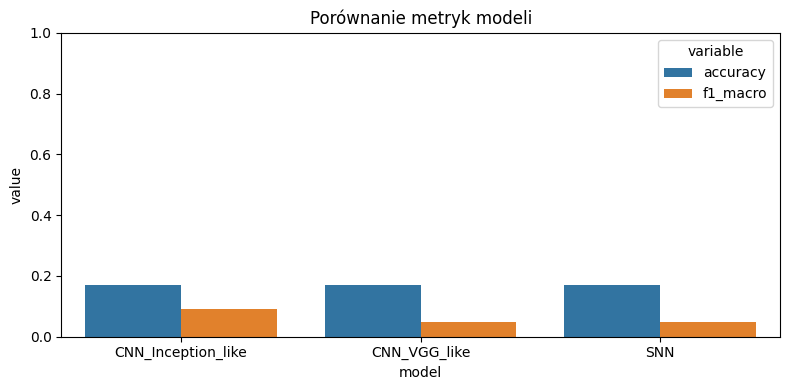

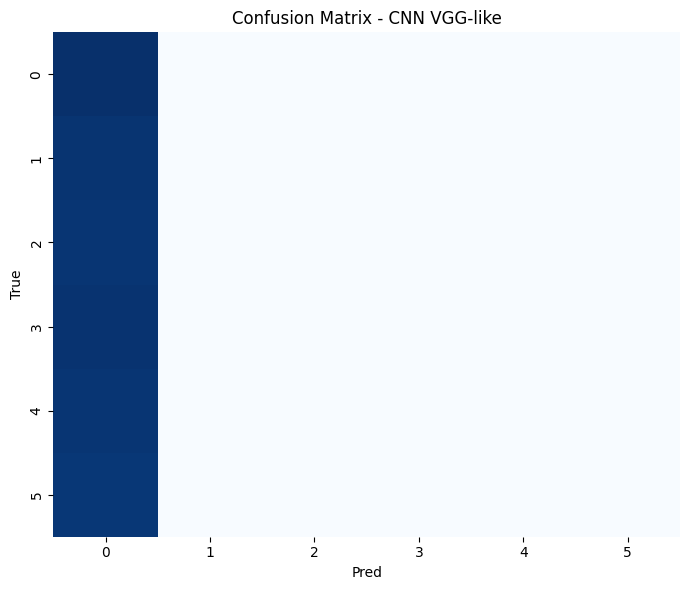

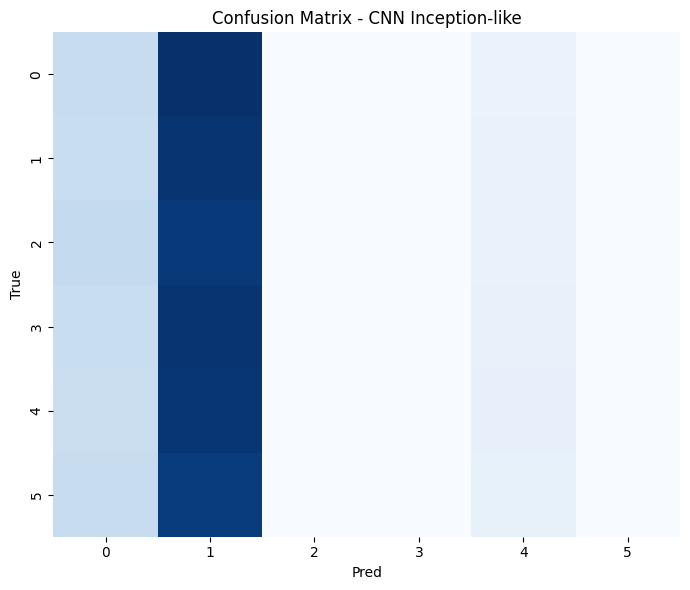

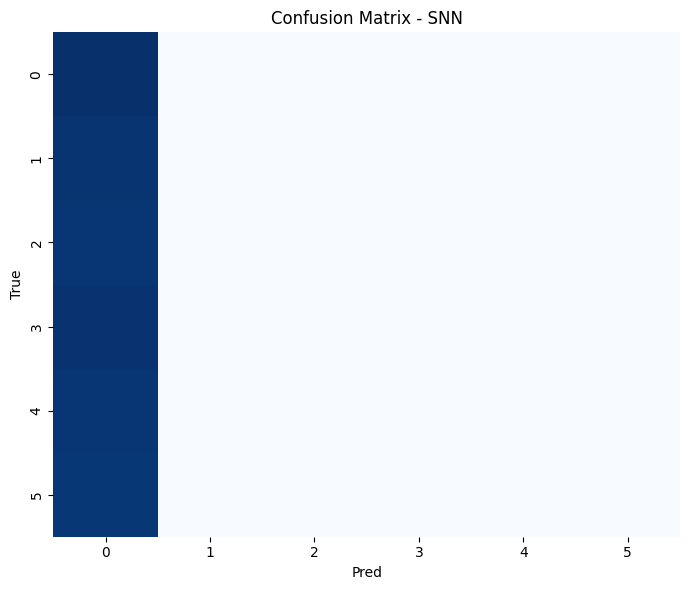

In [11]:
def evaluate_predictions(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

results = [
    evaluate_predictions("CNN_VGG_like", y_true_vgg, y_pred_vgg),
    evaluate_predictions("CNN_Inception_like", y_true_inc, y_pred_inc),
    evaluate_predictions("SNN", y_true_snn, y_pred_snn),
]
results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df.melt(id_vars=["model"], value_vars=["accuracy", "f1_macro"]),
            x="model", y="value", hue="variable")
plt.ylim(0, 1)
plt.title("Porównanie metryk modeli")
plt.tight_layout()
plt.show()

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_cm(y_true_vgg, y_pred_vgg, "Confusion Matrix - CNN VGG-like")
plot_cm(y_true_inc, y_pred_inc, "Confusion Matrix - CNN Inception-like")
plot_cm(y_true_snn, y_pred_snn, "Confusion Matrix - SNN")

## 7. Wizualizacja predykcji z `error_code`

In [12]:
def build_prediction_view(frame, y_pred, y_prob, model_name, n=20):
    tmp = frame.copy().reset_index(drop=True)
    tmp["pred_label"] = y_pred
    tmp["pred_bug_domain"] = tmp["pred_label"].map(id2label)
    tmp["confidence"] = y_prob.max(axis=1)
    tmp["model"] = model_name

    cols = ["model", "bug_domain", "pred_bug_domain", "error_code", "confidence", "text"]
    out = tmp[cols].copy()
    out["text"] = out["text"].str.slice(0, 100)
    return out.sample(min(n, len(out)), random_state=SEED).sort_values("confidence", ascending=False)

pred_vgg_view = build_prediction_view(test_df, y_pred_vgg, y_prob_vgg, "CNN_VGG_like", n=20)
pred_inc_view = build_prediction_view(test_df, y_pred_inc, y_prob_inc, "CNN_Inception_like", n=20)
pred_snn_view = build_prediction_view(test_df, y_pred_snn, y_prob_snn, "SNN", n=20)

print("VGG-like predictions:")
display(pred_vgg_view)
print("Inception-like predictions:")
display(pred_inc_view)
print("SNN predictions:")
display(pred_snn_view)

VGG-like predictions:


,model,bug_domain,pred_bug_domain,error_code,confidence,text
9930,CNN_VGG_like,Mobile,Backend Systems,500.0,0.183289,This issue relates to a ci/cd bug occurring in...
576,CNN_VGG_like,Backend Systems,Backend Systems,401.0,0.183289,This issue relates to a ci/cd bug occurring in...
5272,CNN_VGG_like,Cloud,Backend Systems,400.0,0.175719,This issue relates to a cloud configuration bu...
4521,CNN_VGG_like,Mobile,Backend Systems,403.0,0.174444,This issue relates to a frontend routing bug o...
5653,CNN_VGG_like,Backend Systems,Backend Systems,401.0,0.173907,This issue relates to a logging bug occurring ...
6033,CNN_VGG_like,Mobile,Backend Systems,502.0,0.173887,This issue relates to a api bug occurring in t...
2750,CNN_VGG_like,Data,Backend Systems,nan,0.173887,This issue relates to a deployment bug occurri...
439,CNN_VGG_like,DevOps,Backend Systems,404.0,0.173880,This issue relates to a ui bug occurring in th...
7487,CNN_VGG_like,Web Development,Backend Systems,503.0,0.173880,This issue relates to a ui bug occurring in th...
6252,CNN_VGG_like,Web Development,Backend Systems,500.0,0.173844,This issue relates to a backend logic bug occu...


Inception-like predictions:


,model,bug_domain,pred_bug_domain,error_code,confidence,text
576,CNN_Inception_like,Backend Systems,Backend Systems,401.0,0.204712,This issue relates to a ci/cd bug occurring in...
9930,CNN_Inception_like,Mobile,Backend Systems,500.0,0.204712,This issue relates to a ci/cd bug occurring in...
6252,CNN_Inception_like,Web Development,Mobile,500.0,0.171652,This issue relates to a backend logic bug occu...
7051,CNN_Inception_like,Web Development,Cloud,403.0,0.171379,This issue relates to a memory leak occurring ...
8158,CNN_Inception_like,Backend Systems,Cloud,401.0,0.171379,This issue relates to a memory leak occurring ...
6340,CNN_Inception_like,Backend Systems,Cloud,503.0,0.170469,This issue relates to a authentication bug occ...
5202,CNN_Inception_like,DevOps,Cloud,404.0,0.170469,This issue relates to a authentication bug occ...
439,CNN_Inception_like,DevOps,Cloud,404.0,0.170469,This issue relates to a ui bug occurring in th...
4684,CNN_Inception_like,Backend Systems,Cloud,nan,0.170469,This issue relates to a authentication bug occ...
7487,CNN_Inception_like,Web Development,Cloud,503.0,0.170469,This issue relates to a ui bug occurring in th...


SNN predictions:


,model,bug_domain,pred_bug_domain,error_code,confidence,text
6252,SNN,Web Development,Backend Systems,500.0,0.166667,This issue relates to a backend logic bug occu...
4684,SNN,Backend Systems,Backend Systems,nan,0.166667,This issue relates to a authentication bug occ...
7051,SNN,Web Development,Backend Systems,403.0,0.166667,This issue relates to a memory leak occurring ...
9930,SNN,Mobile,Backend Systems,500.0,0.166667,This issue relates to a ci/cd bug occurring in...
582,SNN,Mobile,Backend Systems,nan,0.166667,This issue relates to a monitoring bug occurri...
6033,SNN,Mobile,Backend Systems,502.0,0.166667,This issue relates to a api bug occurring in t...
3999,SNN,DevOps,Backend Systems,500.0,0.166667,This issue relates to a authorization bug occu...
5653,SNN,Backend Systems,Backend Systems,401.0,0.166667,This issue relates to a logging bug occurring ...
5272,SNN,Cloud,Backend Systems,400.0,0.166667,This issue relates to a cloud configuration bu...
7487,SNN,Web Development,Backend Systems,503.0,0.166667,This issue relates to a ui bug occurring in th...


## 8. Wnioski



- Wszystkie modele mają bardzo zbliżoną accuracy (~0.169), więc ogólna skuteczność klasyfikacji jest niska.
- CNN_Inception_like wypada najlepiej pod względem jakości klasyfikacji wieloklasowej (f1_macro i f1_weighted ~0.0918), wyraźnie lepiej niż pozostałe.
- CNN_VGG_like i SNN osiągnęły praktycznie identyczne, słabe wyniki (f1_macro ~0.048), co sugeruje problemy z rozróżnianiem klas.
- Różnica między accuracy a bardzo niskim F1 wskazuje, że model prawdopodobnie faworyzuje dominujące klasy i słabo radzi sobie z klasami mniejszościowymi.
- W obecnej konfiguracji najlepszą bazą do dalszego strojenia jest Inception-like CNN, ale cały pipeline wymaga poprawy (lepsze cechy, balans klas, tuning hiperparametrów).

In [14]:
best_row = results_df.iloc[0]
worst_row = results_df.iloc[-1]

with open(OUTPUT_DIR / "lab08_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved:", OUTPUT_DIR / "lab08_results.json")

Saved: outputs\lab08\lab08_results.json
